<a href="https://colab.research.google.com/github/nauval135zabidi-collab/citra_digital/blob/main/citra_digital_tugas_pertemuan_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

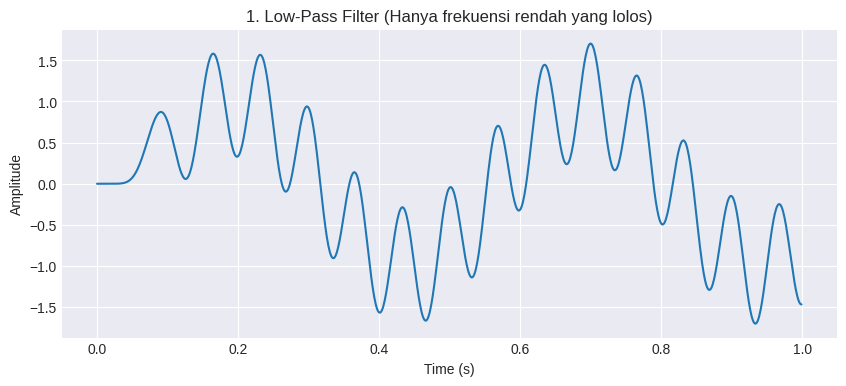

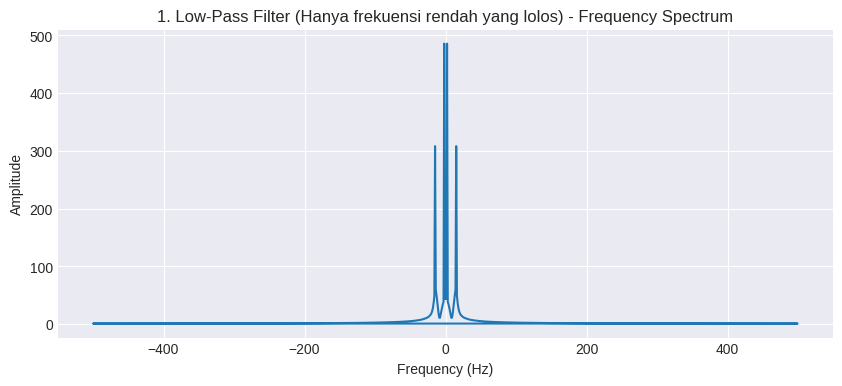

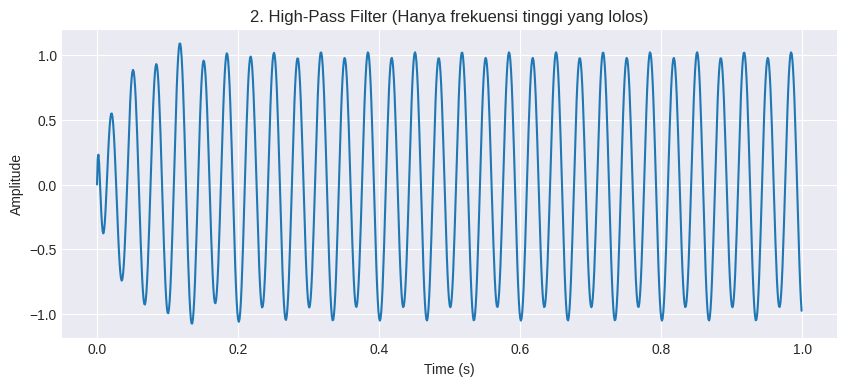

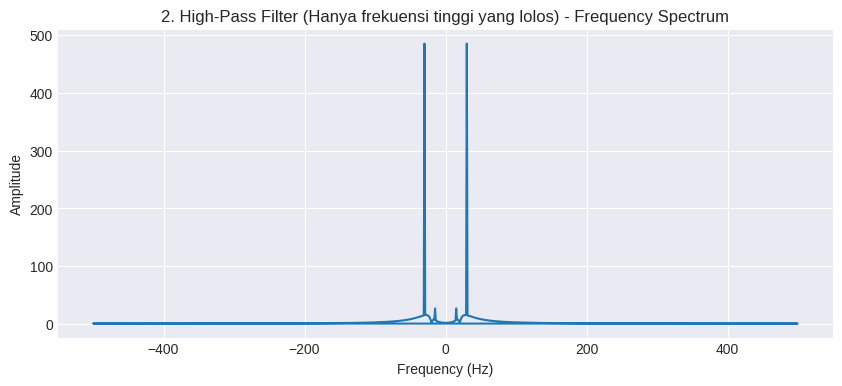

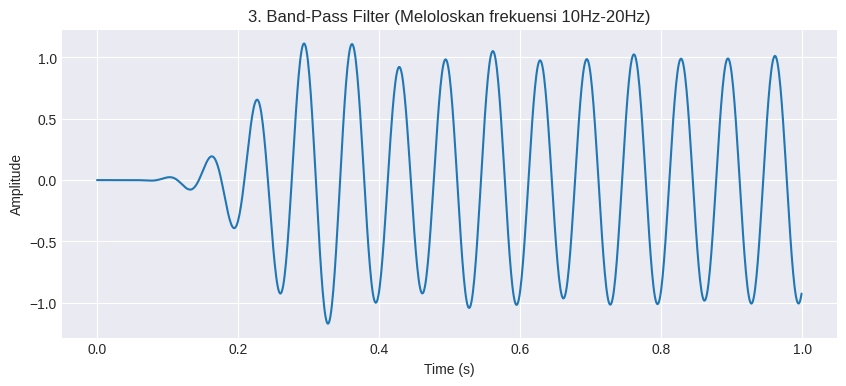

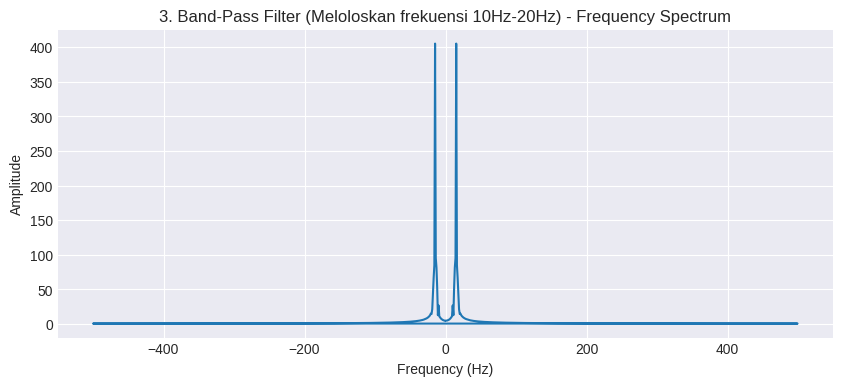

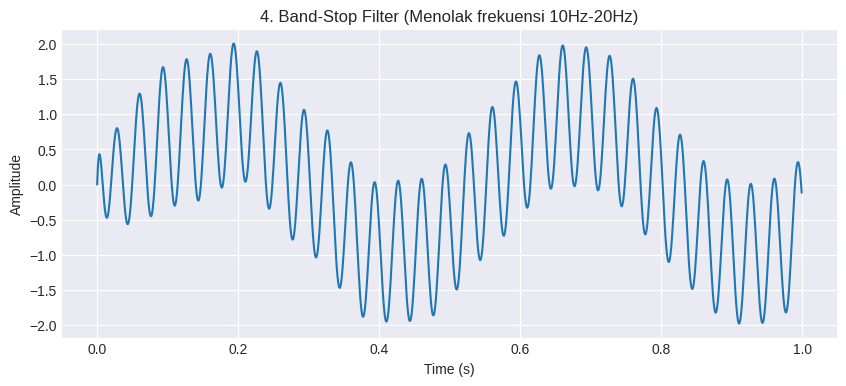

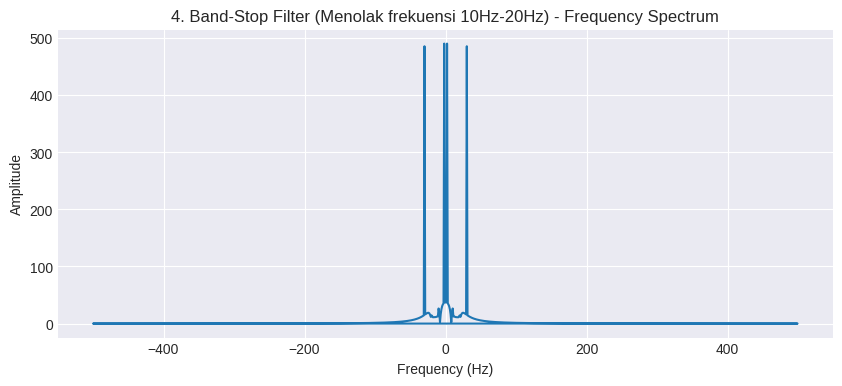

In [6]:
import numpy as np
from scipy.fft import fft, fftfreq
from scipy import signal
import matplotlib.pyplot as plt

# --- 0. DATA INPUT (frekuensi 2Hz, 15Hz, 30Hz) ---
plt.style.use('seaborn-v0_8-darkgrid')

SAMPLE_RATE = 1000  # Hertz
DURATION = 1  # Seconds

fs = SAMPLE_RATE

x = np.linspace(0, DURATION, SAMPLE_RATE * DURATION, endpoint=False)
y = np.sin(2 * np.pi * 2 * x) + np.sin(2 * np.pi * 15 * x) + np.sin(2 * np.pi * 30 * x)

def plot_frequency_spectrum(title, data):
    yf = fft(data)
    xf = fftfreq(len(data), 1 / SAMPLE_RATE)
    plt.figure(figsize=(10, 4))
    plt.plot(xf, np.abs(yf))
    plt.title(title)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.show()

def plot_filter_result(title, data):
    plt.figure(figsize=(10, 4))
    plt.plot(x, data)
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.show()
    plot_frequency_spectrum(title + " - Frequency Spectrum", data)


# --- 1. LOW-PASS FILTER (Meloloskan frekuensi rendah < 10Hz) ---
sos_lp = signal.butter(10, 15, 'lp', fs=fs, output='sos')
low_passed = signal.sosfilt(sos_lp, y)
plot_filter_result("1. Low-Pass Filter (Hanya frekuensi rendah yang lolos)", low_passed)

# --- 2. HIGH-PASS FILTER (Meloloskan frekuensi tinggi > 20Hz) ---
sos_hp = signal.butter(10, 20, 'hp', fs=fs, output='sos')
high_passed = signal.sosfilt(sos_hp, y)
plot_filter_result("2. High-Pass Filter (Hanya frekuensi tinggi yang lolos)", high_passed)

# --- 3. BAND-PASS FILTER (Meloloskan frekuensi antara 10Hz dan 20Hz) ---
sos_bp = signal.butter(10, [10, 20], 'bandpass', fs=fs, output='sos')
band_passed = signal.sosfilt(sos_bp, y)
plot_filter_result("3. Band-Pass Filter (Meloloskan frekuensi 10Hz-20Hz)", band_passed)

# --- 4. BAND-STOP FILTER (Menolak frekuensi antara 10Hz dan 20Hz) ---
sos_bs = signal.butter(10, [10, 20], 'bandstop', fs=fs, output='sos')
band_stopped = signal.sosfilt(sos_bs, y)
plot_filter_result("4. Band-Stop Filter (Menolak frekuensi 10Hz-20Hz)", band_stopped)
